# O Problema do Caixeiro Viajante: Solução por Simulated Annealing


Vinicius Trindade Dias Abel - 2020007112

## Implementação

In [ ]:
import numpy as np
import numpy.typing as npt
import scipy
import matplotlib.pyplot as plt
from numba import jit

In [ ]:
def gerar_grafo_aleatorio(numero_de_nos: np.int_) -> npt.NDArray[np.float_]:
    nos: npt.NDArray[np.float_] = np.random.rand(numero_de_nos, 2)
    matriz_adjacencia: npt.NDArray[np.float_] = scipy.spatial.distance_matrix(nos, nos)
    return matriz_adjacencia, nos

In [ ]:
def plotar_caminho(nos: npt.NDArray[np.float_], caminho: npt.NDArray[np.int_], custo_caminho: np.float_) -> None:
    plt.figure(figsize=(4, 4))
    plt.title(f"Custo do caminho: {custo_caminho}")
    plt.scatter(nos[:, 0], nos[:, 1], c="black")
    for i in range(caminho.shape[0] - 1):
        coordenadas_x: npt.NDArray[np.float_] = np.array([nos[caminho[i]][0], nos[caminho[i + 1]][0]])
        coordenadas_y: npt.NDArray[np.float_] = np.array([nos[caminho[i]][1], nos[caminho[i + 1]][1]])
        plt.plot(coordenadas_x, coordenadas_y, "b-")
    plt.show()

In [ ]:
def plotar_distancia_temperatura(distancias: npt.NDArray[np.float_], temperaturas: npt.NDArray[np.float_], numero_de_cidades: np.float_, temperatura_inicial: np.float_, delta_t: np.float_, limite_inferior_temperatura: np.float_) -> None:
    _, ax1 = plt.subplots(figsize=(6, 4))
    ax1.plot(distancias, color="blue")
    ax1.set_ylabel("Distância percorrida no caminho escolhido", color="blue")
    ax1.set_xlabel("Passos de Monte Carlo")

    ax2 = ax1.twinx()
    ax2.plot(temperaturas, color="red")
    ax2.set_ylabel("Temperatura", color="red")

    plt.title(f"Número de cidades: {numero_de_cidades}, Temperatura inicial: {temperatura_inicial}\n Delta T: {delta_t}, Limite inferior de temperatura: {limite_inferior_temperatura}")
    plt.show()

In [ ]:
@jit(nopython=True)
def realizar_passos_monte_carlo(numero_de_passos_monte_carlo: np.int_, numero_de_cidades: np.int_, temperatura: np.float_, grafo: npt.NDArray[np.float_], nos: npt.NDArray[np.float_], caminho_atual: npt.NDArray[np.int_], custo_caminho_atual: np.float_) -> np.float_:
    for _ in range(numero_de_passos_monte_carlo):
        for _ in range(numero_de_cidades):
            x_proposto, y_proposto = np.sort(np.random.choice(np.arange(numero_de_cidades), size=2, replace=False))
            caminho_atual = np.roll(caminho_atual, shift=1)
            caminho_proposto: npt.NDArray[np.int_] = caminho_atual.copy()
            caminho_proposto[x_proposto + 1: y_proposto] = np.flip(caminho_proposto[x_proposto + 1: y_proposto])

            custo_remover_aresta_1: np.float_ = grafo[caminho_atual[x_proposto]][caminho_atual[(x_proposto + 1) % numero_de_cidades]]
            custo_remover_aresta_2: np.float_ = grafo[caminho_atual[y_proposto - 1]][caminho_atual[y_proposto]]
            custo_adicionar_aresta_1: np.float_ = grafo[caminho_proposto[x_proposto]][caminho_proposto[(x_proposto + 1) % numero_de_cidades]]
            custo_adicionar_aresta_2: np.float_ = grafo[caminho_proposto[y_proposto - 1]][caminho_proposto[y_proposto]]

            decrescimo: np.float_ = custo_remover_aresta_1 + custo_remover_aresta_2
            aumento: np.float_ = custo_adicionar_aresta_1 + custo_adicionar_aresta_2
            custo_caminho_proposto: np.float_ = custo_caminho_atual - decrescimo + aumento
            delta: np.float_ = custo_caminho_proposto - custo_caminho_atual
            r: np.float_ = np.random.rand()
            P: np.float_ = np.exp(-1 * delta / temperatura)
            if delta < 0 or r <= P:
                caminho_atual = caminho_proposto.copy()
                custo_caminho_atual = custo_caminho_proposto
    return caminho_atual, custo_caminho_atual

In [ ]:
def caixeiro_viajante(grafo: npt.NDArray[np.float_], nos: npt.NDArray[np.float_], temperatura: np.float_, delta_t: np.float_, limite_inferior_temperatura: np.float_) -> tuple:
    numero_de_passos_monte_carlo: np.int_ = 1  # hard coded
    numero_de_cidades: np.int_ = grafo.shape[0]
    caminho_atual: npt.NDArray[np.int_] = np.arange(numero_de_cidades)
    np.random.shuffle(caminho_atual)
    arestas: npt.NDArray[np.int_] = np.append(np.lib.stride_tricks.sliding_window_view(caminho_atual, 2), [[caminho_atual[-1], caminho_atual[0]]], axis=0)
    custo_caminho_atual: np.float_ = np.sum([grafo[i, j] for i, j in arestas])

    temperaturas: list[float] = []
    distancias: list[float] = []

    while temperatura > limite_inferior_temperatura:
        temperaturas.append(temperatura)
        distancias.append(custo_caminho_atual)
        caminho_atual, custo_caminho_atual = realizar_passos_monte_carlo(
            numero_de_passos_monte_carlo=numero_de_passos_monte_carlo,
            numero_de_cidades=numero_de_cidades,
            temperatura=temperatura,
            grafo=grafo,
            nos=nos,
            caminho_atual=caminho_atual,
            custo_caminho_atual=custo_caminho_atual
        )
        temperatura *= delta_t

    caminho_atual = np.append(caminho_atual, caminho_atual[0])
    return caminho_atual, custo_caminho_atual, nos, distancias, temperaturas

## Simulações

### 10 Cidades

In [ ]:
NUMERO_DE_CIDADES: np.int_ = 10
GRAFO, NOS = gerar_grafo_aleatorio(numero_de_nos=NUMERO_DE_CIDADES)

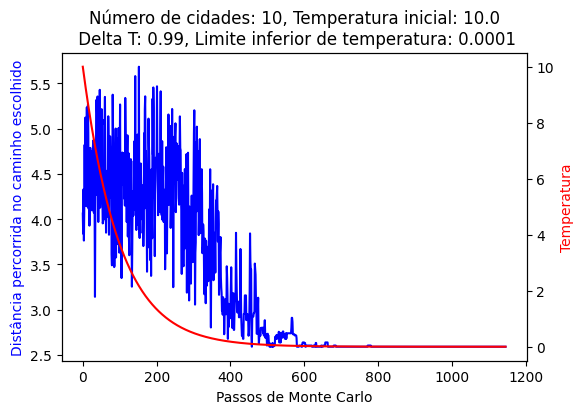

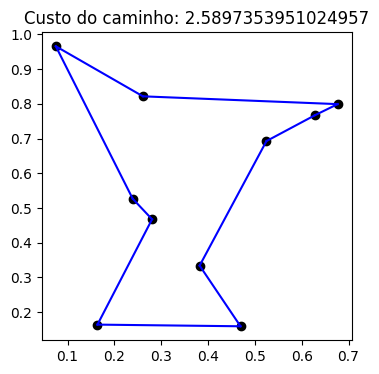

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

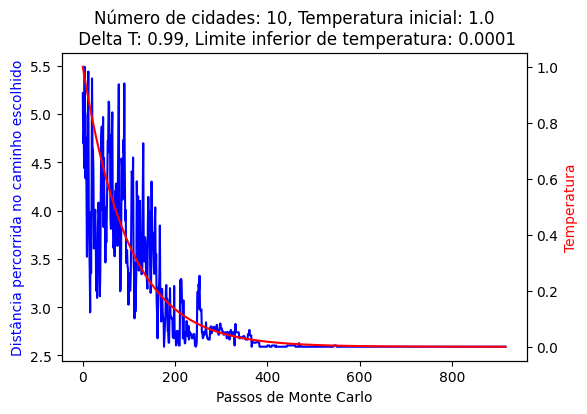

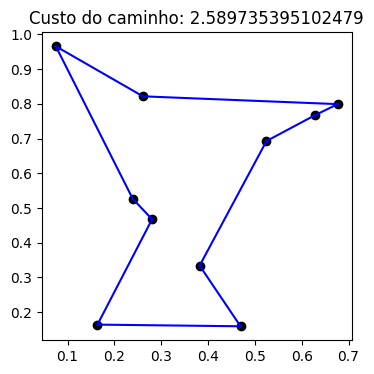

In [ ]:
temperatura: np.float_ = 1.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

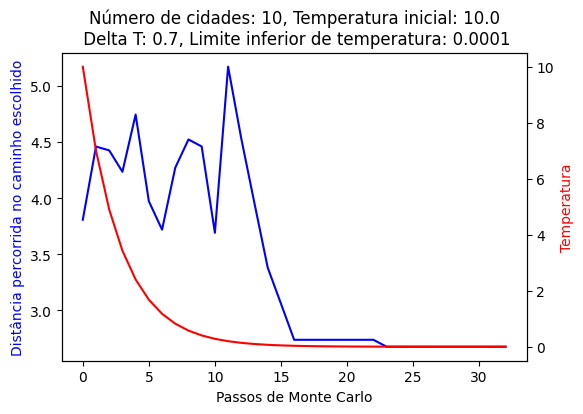

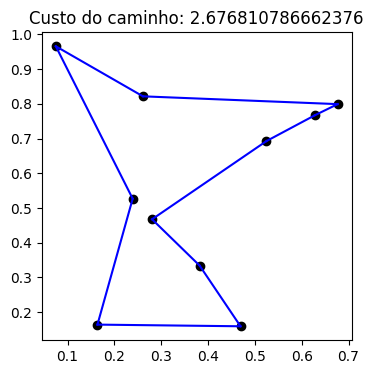

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.70
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

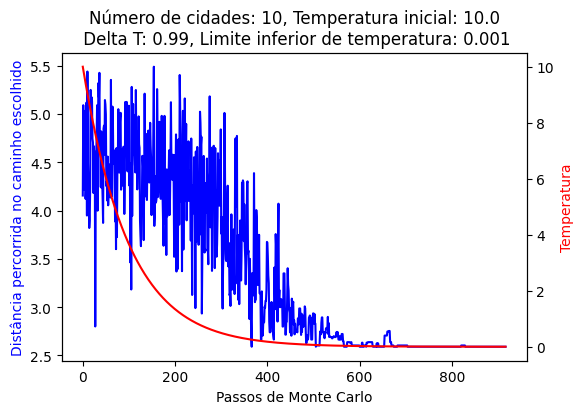

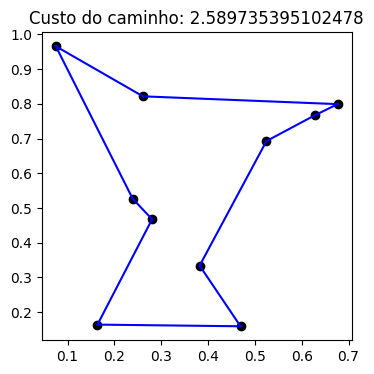

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

### 50 Cidades

In [ ]:
NUMERO_DE_CIDADES: np.int_ = 50
GRAFO, NOS = gerar_grafo_aleatorio(numero_de_nos=NUMERO_DE_CIDADES)

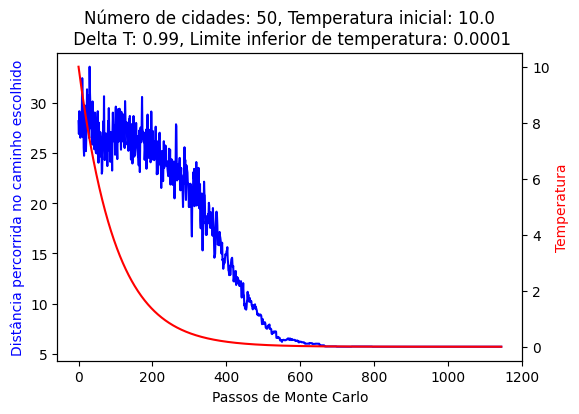

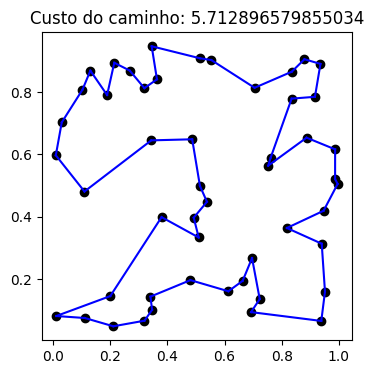

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

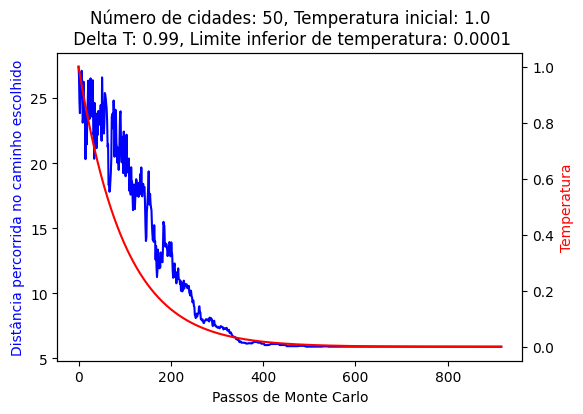

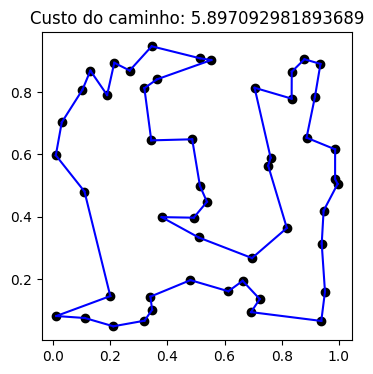

In [ ]:
temperatura: np.float_ = 1.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

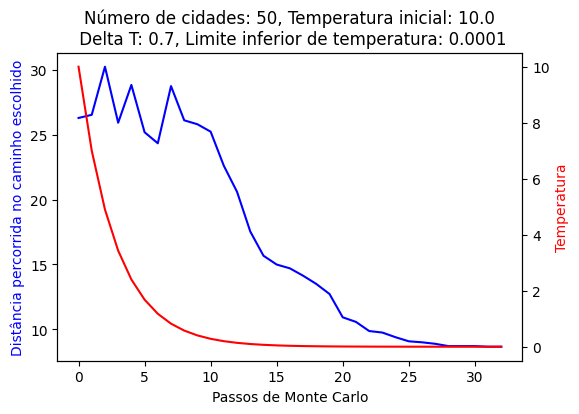

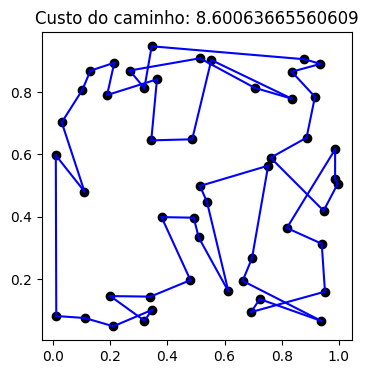

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.7
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

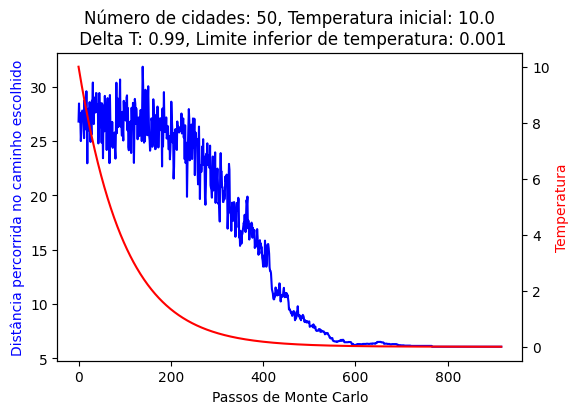

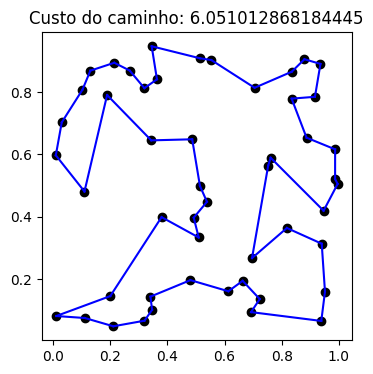

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

### 100 Cidades

In [ ]:
NUMERO_DE_CIDADES: np.int_ = 100
GRAFO, NOS = gerar_grafo_aleatorio(numero_de_nos=NUMERO_DE_CIDADES)

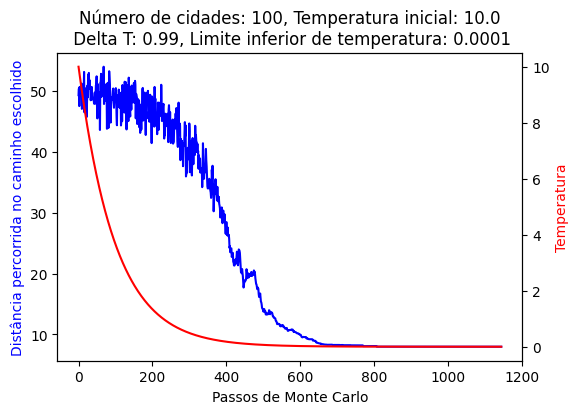

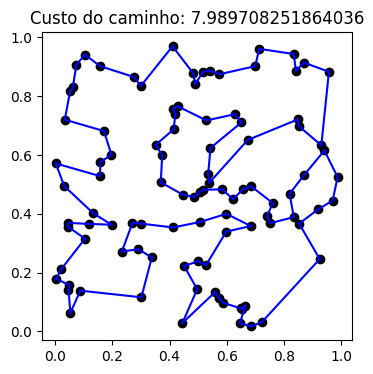

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

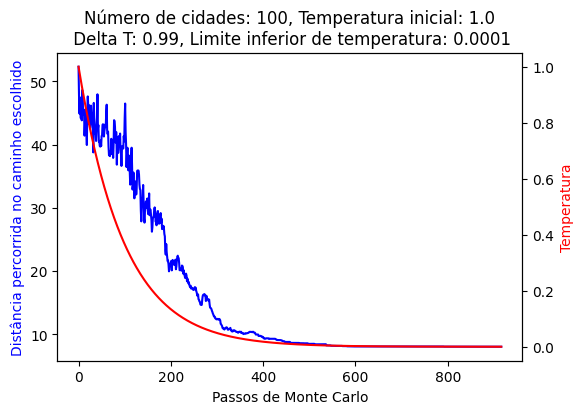

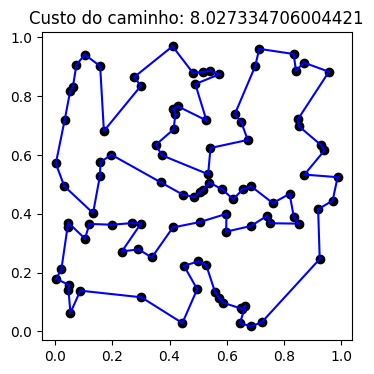

In [ ]:
temperatura: np.float_ = 1.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

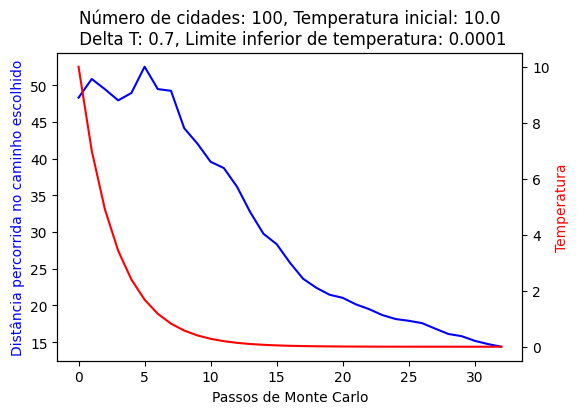

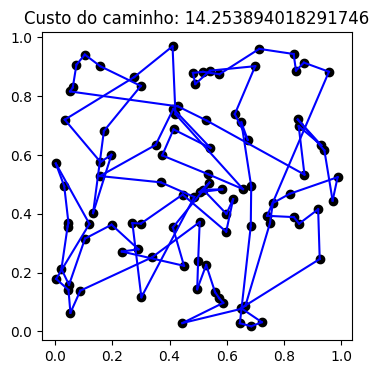

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.7
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

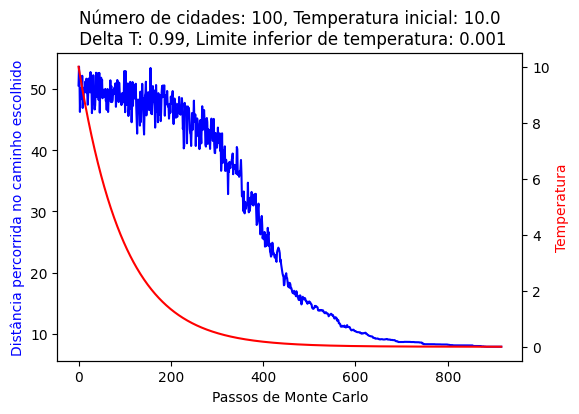

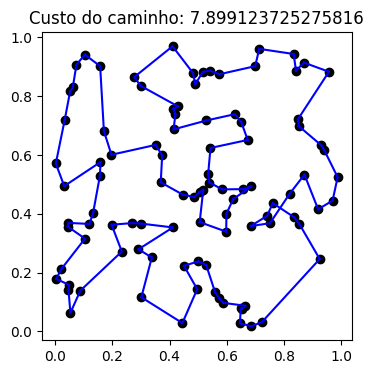

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

### 150 Cidades

In [ ]:
NUMERO_DE_CIDADES: np.int_ = 150
GRAFO, NOS = gerar_grafo_aleatorio(numero_de_nos=NUMERO_DE_CIDADES)

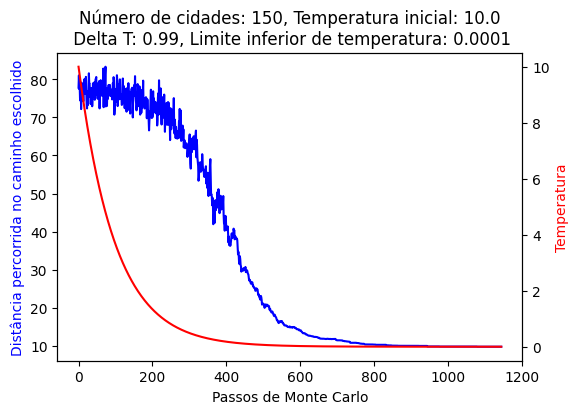

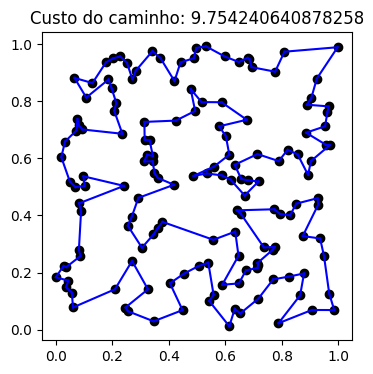

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

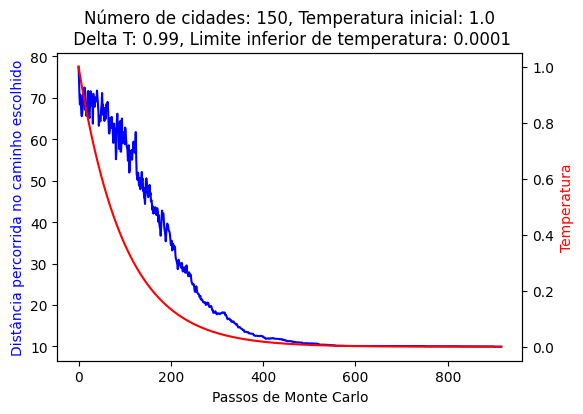

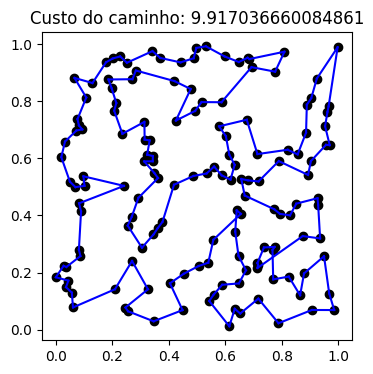

In [ ]:
temperatura: np.float_ = 1.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

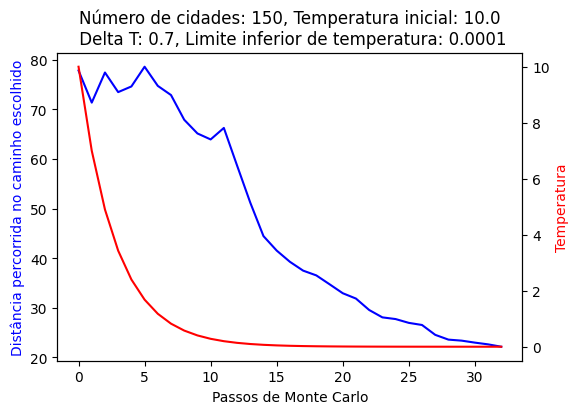

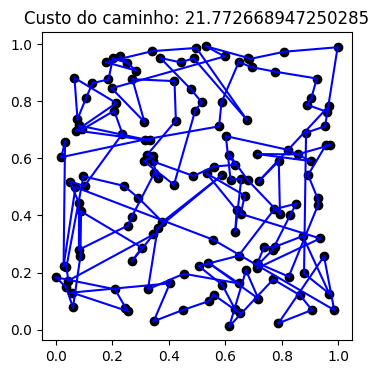

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.7
limite_inferior_temperatura: np.float_ = 0.0001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

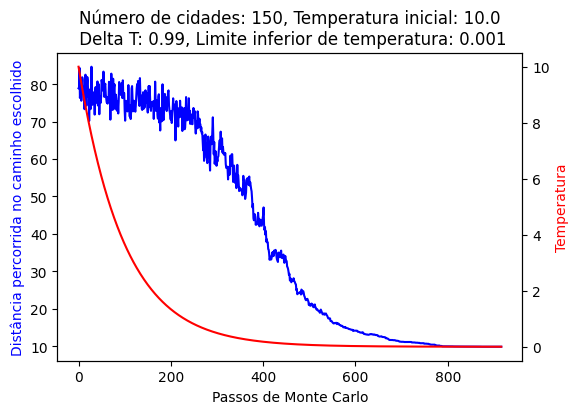

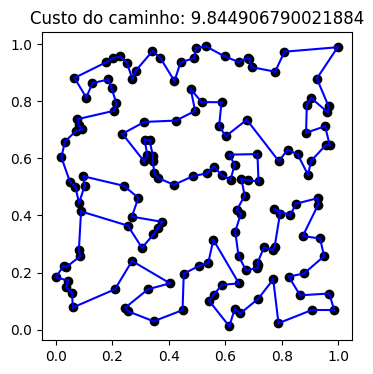

In [ ]:
temperatura: np.float_ = 10.0
delta_t: np.float_ = 0.99
limite_inferior_temperatura: np.float_ = 0.001

caminho, custo_caminho, nos, distancias, temperaturas = caixeiro_viajante(
    grafo=GRAFO,
    nos=NOS,
    temperatura=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_distancia_temperatura(
    distancias=distancias,
    temperaturas=temperaturas,
    numero_de_cidades=NUMERO_DE_CIDADES,
    temperatura_inicial=temperatura,
    delta_t=delta_t,
    limite_inferior_temperatura=limite_inferior_temperatura
)

plotar_caminho(
    nos=nos,
    caminho=caminho,
    custo_caminho=custo_caminho
)

## Análise de Resultados

Nessa análise, explorei como os parâmetros do Simulated Annealing influenciam na solução do problema do Caixeiro Viajante. O objetivo foi entender o impacto de variáveis como a temperatura inicial, a taxa de decaimento e o limite inferior da temperatura, além de como o número de cidades afeta o desempenho do método.

Os resultados foram avaliados observando:
- O custo total do caminho encontrado;
- A qualidade do caminho (se possui cruzamentos ou não);
- O comportamento do algoritmo ao longo das iterações.

---

### Resultados e Discussões

#### Temperaturas Iniciais
Testei diferentes valores de temperatura inicial, como 1.0 e 10.0, e vi que:
- Quando a temperatura inicial é alta, o algoritmo começa explorando muitas possibilidades, o que ajuda a escapar de mínimos locais. Isso geralmente leva a resultados melhores, com custos mais baixos.
- Já valores baixos de temperatura inicial fazem o algoritmo começar mais "conservador", convergindo rápido, mas com maior chance de ficar preso em soluções ruins.

#### Taxa de Decaimento
Experimentei taxas de decaimento em 0.7 e 0.99. O impacto foi bem claro:
- Com (decaimento = 0.99), o decaimento é lento, permitindo que o algoritmo explore mais caminhos. Isso resultou em soluções de melhor qualidade.
- Já com (decaimento = 0.7), a redução de temperatura foi muito rápida, limitando as iterações e levando a soluções menos refinadas. O custo final foi maior, e houve caminhos com cruzamentos.

#### Limite Inferior da Temperatura
Testei temperatura minima com 0.0001 e 0.001, e os resultados mostraram que:
- Uma temperatura minima menor permitiu ao algoritmo mais passos em temperaturas baixas, o que ajudou a melhorar o ajuste fino do caminho.
- Quando a temperatura minima era maior, o algoritmo parou mais cedo, o que prejudicou a solução em alguns casos, principalmente nos problemas maiores.

#### Número de Cidades
Variei o número de cidades entre 10, 50, 100 e 150. Os resultados foram como esperado:
- Com 10 cidades, o método encontrou boas soluções rapidamente, já que o problema é simples.
- Conforme aumentei para 50, 100 e 150 cidades, ficou mais difícil obter resultados próximos do ótimo. Isso tornou a escolha dos parâmetros ainda mais importante.

---

### Conclusão
No geral, o Simulated Annealing funcionou bem, especialmente para problemas pequenos e médios (até 50 cidades). Para problemas maiores, os parâmetros precisam ser ajustados com cuidado:
- Temperaturas iniciais altas são melhores para explorar mais o espaço de soluções.
- Taxas de decaimento lentas (taxas de decaimento perto de 0.99) garantem mais passos de Monte Carlo, o que ajuda a encontrar soluções de melhor qualidade.
- Uma temperatura minima baixa permite um ajuste mais fino no final do processo, mas pode aumentar o tempo de execução.
